In [1]:
from PIL import Image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from os import listdir
import numpy as np
import pandas as pd

2025-12-11 03:22:02.556722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765423322.581941   34710 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765423322.590715   34710 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765423322.621014   34710 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765423322.621056   34710 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765423322.621059   34710 computation_placer.cc:177] computation placer alr

In [2]:
birdpath = "/code/Final-Project/data/BirdAI"
catpath = "/code/Final-Project/data/CatAI"
deerpath = "/code/Final-Project/data/DeerAI"
dogpath = "/code/Final-Project/data/DogAI"
frogpath = "/code/Final-Project/data/FrogAI"
horsepath = "/code/Final-Project/data/HorseAI"

paths = {
    "bird": birdpath,
    "cat": catpath,
    "deer": deerpath,
    "dog": dogpath,
    "frog": frogpath,
    "horse": horsepath
}

class_names = ["bird", "cat", "deer", "dog", "frog", "horse"]
label_map = {name: i for i, name in enumerate(class_names)}

In [3]:
label_map

{'bird': 0, 'cat': 1, 'deer': 2, 'dog': 3, 'frog': 4, 'horse': 5}

In [4]:
dat = pd.DataFrame(columns = ["Path", "Class", "Encoded_Class", "Image", "DataType", "Stage"])

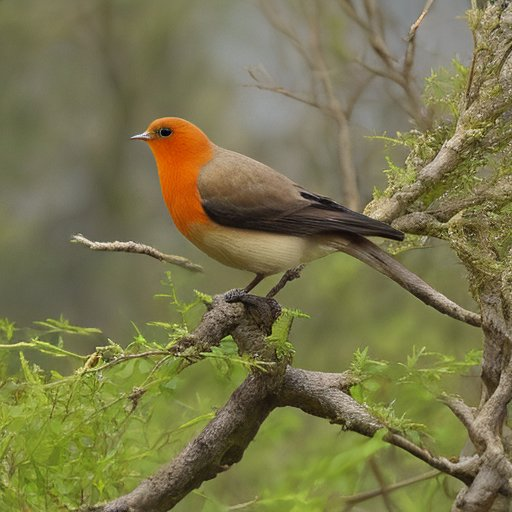

In [5]:
Image.open("/code/Final-Project/data/BirdAI/bird_1439.jpg")

In [6]:
dpaths = []
classes = []
dattypes = []
X_synth = []
y_synth = []

# Load colored images
for name, path in paths.items():
    for img_name in os.listdir(path):
        if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(path, img_name)
            dpaths.append(img_path)
            img = load_img(img_path, color_mode="rgb", target_size=(32, 32))
            
            img_array = img_to_array(img)    
            X_synth.append(img_array)
            y_synth.append(label_map[name])
            classes.append(name)
# Convert to numpy arrays

# X_synth = np.array(X_synth)
# y_synth = np.array(y_synth)

dat['Path'] = dpaths
dat['Class'] = classes
dat['Encoded_Class'] = y_synth
dat['Image'] = X_synth
dat['DataType'] = 'synth'

# # Shuffle before splitting
# idx = np.arange(len(X_synth))
# np.random.shuffle(idx)

# X_synth = X_synth[idx]
# y_synth = y_synth[idx]

# print("Loaded X shape:", X_synth.shape)   
# print("Loaded y shape:", y_synth.shape)

In [7]:
dat['Stage'] = 'train'

In [8]:
dat

,Path,Class,Encoded_Class,Image,DataType,Stage
0,/code/Final-Project/data/BirdAI/bird_2930.jpg,bird,0,"[[[64.0, 90.0, 16.0], [69.0, 91.0, 18.0], [74....",synth,train
1,/code/Final-Project/data/BirdAI/bird_1439.jpg,bird,0,"[[[117.0, 118.0, 78.0], [117.0, 117.0, 81.0], ...",synth,train
2,/code/Final-Project/data/BirdAI/bird_1595.jpg,bird,0,"[[[109.0, 116.0, 72.0], [124.0, 125.0, 85.0], ...",synth,train
3,/code/Final-Project/data/BirdAI/bird_2378.jpg,bird,0,"[[[94.0, 85.0, 52.0], [112.0, 101.0, 73.0], [1...",synth,train
4,/code/Final-Project/data/BirdAI/bird_781.jpg,bird,0,"[[[108.0, 117.0, 50.0], [129.0, 132.0, 65.0], ...",synth,train
...,...,...,...,...,...,...
17995,/code/Final-Project/data/HorseAI/horse_852.jpg,horse,5,"[[[157.0, 160.0, 167.0], [163.0, 166.0, 173.0]...",synth,train
17996,/code/Final-Project/data/HorseAI/horse_824.jpg,horse,5,"[[[163.0, 171.0, 184.0], [165.0, 173.0, 184.0]...",synth,train
17997,/code/Final-Project/data/HorseAI/horse_2850.jpg,horse,5,"[[[165.0, 173.0, 186.0], [167.0, 173.0, 185.0]...",synth,train
17998,/code/Final-Project/data/HorseAI/horse_279.jpg,horse,5,"[[[174.0, 159.0, 152.0], [138.0, 119.0, 113.0]...",synth,train


In [9]:
print("Total images:", np.array(dat['Image'].to_list()).shape)
print("Total labels:", np.array(dat['Encoded_Class'].to_list()).shape)

Total images: (18000, 32, 32, 3)
Total labels: (18000,)


In [10]:
dat.iloc[8]

Path                  /code/Final-Project/data/BirdAI/bird_324.jpg
Class                                                         bird
Encoded_Class                                                    0
Image            [[[118.0, 126.0, 79.0], [111.0, 120.0, 65.0], ...
DataType                                                     synth
Stage                                                        train
Name: 8, dtype: object

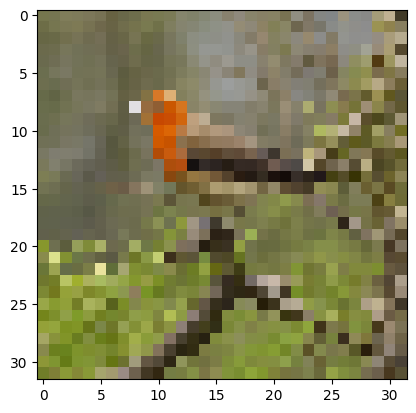

In [11]:
plt.imshow(dat['Image'][1]/255.0)
plt.show()

In [12]:
print("Min pixel value:", np.array(dat['Image'].to_list()).min())
print("Max pixel value:", np.array(dat['Image'].to_list()).max())

Min pixel value: 0.0
Max pixel value: 255.0


In [13]:
dat['Image'] = dat['Image'].apply(lambda x: x/255.0)

In [14]:
dat

,Path,Class,Encoded_Class,Image,DataType,Stage
0,/code/Final-Project/data/BirdAI/bird_2930.jpg,bird,0,"[[[0.2509804, 0.3529412, 0.0627451], [0.270588...",synth,train
1,/code/Final-Project/data/BirdAI/bird_1439.jpg,bird,0,"[[[0.45882353, 0.4627451, 0.30588236], [0.4588...",synth,train
2,/code/Final-Project/data/BirdAI/bird_1595.jpg,bird,0,"[[[0.42745098, 0.45490196, 0.28235295], [0.486...",synth,train
3,/code/Final-Project/data/BirdAI/bird_2378.jpg,bird,0,"[[[0.36862746, 0.33333334, 0.20392157], [0.439...",synth,train
4,/code/Final-Project/data/BirdAI/bird_781.jpg,bird,0,"[[[0.42352942, 0.45882353, 0.19607843], [0.505...",synth,train
...,...,...,...,...,...,...
17995,/code/Final-Project/data/HorseAI/horse_852.jpg,horse,5,"[[[0.6156863, 0.627451, 0.654902], [0.6392157,...",synth,train
17996,/code/Final-Project/data/HorseAI/horse_824.jpg,horse,5,"[[[0.6392157, 0.67058825, 0.72156864], [0.6470...",synth,train
17997,/code/Final-Project/data/HorseAI/horse_2850.jpg,horse,5,"[[[0.64705884, 0.6784314, 0.7294118], [0.65490...",synth,train
17998,/code/Final-Project/data/HorseAI/horse_279.jpg,horse,5,"[[[0.68235296, 0.62352943, 0.59607846], [0.541...",synth,train


In [15]:
X_synth_train = np.array(dat['Image'].to_list())
y_synth_train = np.array(dat['Encoded_Class'].to_list())

In [16]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# X_synth_train, X_synth_test, y_synth_train, y_synth_test = train_test_split(X_synth, y_synth, test_size = 0.25, random_state = 43, stratify = y_synth)

y_synth_train = to_categorical(y_synth_train, 6)
# y_synth_test = to_categorical(y_synth_test, 6)

In [17]:
# Shuffle before splitting
idx = np.arange(len(X_synth_train))
np.random.shuffle(idx)

X_synth_train = X_synth_train[idx]
y_synth_train = y_synth_train[idx]

Displaying first 5 training images:


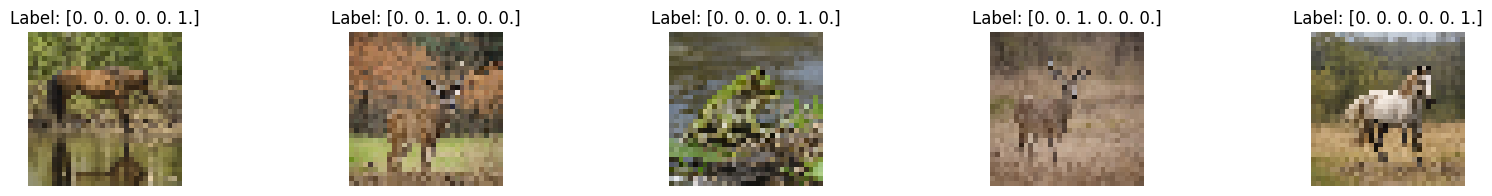

In [18]:
# Plot for visualization of the first 5 color images
plt.figure(figsize=(20, 2)) 
print("Displaying first 5 training images:")

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_synth_train[i])  # Ensure correct type
    plt.axis('off')
    plt.title(f"Label: {y_synth_train[i]}")
plt.show()

In [19]:
y_synth_train.shape

(18000, 6)

In [20]:
from keras.applications.vgg16 import VGG16
from keras.models import Model, Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
model_CIFAR = Sequential()

model_CIFAR.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model_CIFAR.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model_CIFAR.add(MaxPooling2D(pool_size=(2, 2)))

model_CIFAR.add(Conv2D(64, kernel_size=(3, 3), activation = 'relu', padding='same'))
model_CIFAR.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model_CIFAR.add(MaxPooling2D(pool_size=(2, 2)))

model_CIFAR.add(Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))
model_CIFAR.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model_CIFAR.add(MaxPooling2D(pool_size=(2, 2)))

model_CIFAR.add(Flatten())
model_CIFAR.add(Dropout(0.5))

model_CIFAR.add(Dense(512, activation='relu'))

# Fully connected layer with num_classes neurons 
model_CIFAR.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-11 03:22:40.626652: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [22]:
model_CIFAR.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,694 (1.48 MB)

 Trainable params: 386,694 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_CIFAR.compile(optimizer='adam', loss= 'categorical_crossentropy', metrics=['accuracy'])

In [24]:
early_stopping_callback = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)

In [25]:
model_CIFAR.fit(X_synth_train, y_synth_train, validation_split=0.2, epochs=30, batch_size=120, verbose=2, callbacks = [early_stopping_callback])

Epoch 1/30
120/120 - 15s - 121ms/step - accuracy: 0.6587 - loss: 0.8733 - val_accuracy: 0.8733 - val_loss: 0.3436
Epoch 2/30
120/120 - 12s - 102ms/step - accuracy: 0.9252 - loss: 0.2227 - val_accuracy: 0.9661 - val_loss: 0.1039
Epoch 3/30
120/120 - 20s - 169ms/step - accuracy: 0.9493 - loss: 0.1543 - val_accuracy: 0.9711 - val_loss: 0.0855
Epoch 4/30
120/120 - 12s - 99ms/step - accuracy: 0.9626 - loss: 0.1108 - val_accuracy: 0.9817 - val_loss: 0.0554
Epoch 5/30
120/120 - 12s - 101ms/step - accuracy: 0.9746 - loss: 0.0748 - val_accuracy: 0.9878 - val_loss: 0.0369
Epoch 6/30
120/120 - 12s - 100ms/step - accuracy: 0.9834 - loss: 0.0494 - val_accuracy: 0.9917 - val_loss: 0.0306
Epoch 7/30
120/120 - 12s - 98ms/step - accuracy: 0.9851 - loss: 0.0448 - val_accuracy: 0.9903 - val_loss: 0.0341
Epoch 8/30
120/120 - 12s - 97ms/step - accuracy: 0.9862 - loss: 0.0407 - val_accuracy: 0.9914 - val_loss: 0.0295
Epoch 9/30
120/120 - 12s - 100ms/step - accuracy: 0.9863 - loss: 0.0412 - val_accuracy: 0.9

In [26]:
from keras.datasets import cifar10

In [27]:
(x_real_train, y_real_train), (x_real_test, y_real_test) = cifar10.load_data()

In [28]:
class_map = {2: "bird", 3: "cat", 4: "deer", 5: "dog", 6: "frog", 7: "horse"}

In [29]:
y_real_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [30]:
dat2 = pd.DataFrame(columns = ["Class", "Encoded_Class", "Image", "DataType", "Stage"])
names = []
imgs = []
enc_classes = []
for img, lab in zip(x_real_train, y_real_train):
    if lab[0] in [2,3,4,5,6,7]:
        names.append(class_map[lab[0]])
        imgs.append(img)
        enc_classes.append(lab[0])

In [31]:
dat2['Image'] = imgs
dat2['Class'] = names
dat2['Encoded_Class'] = enc_classes

In [32]:
dat2['Image'] = dat2['Image'].apply(lambda x: x/255.0)

In [33]:
dat2

,Class,Encoded_Class,Image,DataType,Stage
0,frog,6,"[[[0.23137254901960785, 0.24313725490196078, 0...",NaN,NaN
1,deer,4,"[[[0.10980392156862745, 0.09803921568627451, 0...",NaN,NaN
2,bird,2,"[[[0.6431372549019608, 0.807843137254902, 0.32...",NaN,NaN
3,horse,7,"[[[0.10980392156862745, 0.13725490196078433, 0...",NaN,NaN
4,cat,3,"[[[0.49019607843137253, 0.49019607843137253, 0...",NaN,NaN
...,...,...,...,...,...
29995,dog,5,"[[[0.6313725490196078, 0.6509803921568628, 0.6...",NaN,NaN
29996,deer,4,"[[[0.8862745098039215, 0.8980392156862745, 0.9...",NaN,NaN
29997,bird,2,"[[[0.7372549019607844, 0.7647058823529411, 0.7...",NaN,NaN
29998,bird,2,"[[[0.5686274509803921, 0.6313725490196078, 0.7...",NaN,NaN


In [34]:
dat2['Stage'] = 'train/val'

In [35]:
dat2['Class'].unique()

array(['frog', 'deer', 'bird', 'horse', 'cat', 'dog'], dtype=object)

In [36]:
dat2

,Class,Encoded_Class,Image,DataType,Stage
0,frog,6,"[[[0.23137254901960785, 0.24313725490196078, 0...",NaN,train/val
1,deer,4,"[[[0.10980392156862745, 0.09803921568627451, 0...",NaN,train/val
2,bird,2,"[[[0.6431372549019608, 0.807843137254902, 0.32...",NaN,train/val
3,horse,7,"[[[0.10980392156862745, 0.13725490196078433, 0...",NaN,train/val
4,cat,3,"[[[0.49019607843137253, 0.49019607843137253, 0...",NaN,train/val
...,...,...,...,...,...
29995,dog,5,"[[[0.6313725490196078, 0.6509803921568628, 0.6...",NaN,train/val
29996,deer,4,"[[[0.8862745098039215, 0.8980392156862745, 0.9...",NaN,train/val
29997,bird,2,"[[[0.7372549019607844, 0.7647058823529411, 0.7...",NaN,train/val
29998,bird,2,"[[[0.5686274509803921, 0.6313725490196078, 0.7...",NaN,train/val


In [37]:
names = []
imgs = []
enc_classes = []
stages = []
for img, lab in zip(x_real_test, y_real_test):
    if lab[0] in [2,3,4,5,6,7]:
        names.append(class_map[lab[0]])
        imgs.append(img)
        enc_classes.append(lab[0])
        stages.append('test')

In [38]:
df = pd.DataFrame({"Class": names, "Encoded_Class": enc_classes, "Image": imgs, "Stage": stages})
df['Image'] = df['Image'].apply(lambda x: x/255.0)
df.reset_index(drop=True, inplace=True)
dat2 = pd.concat([dat2, df], ignore_index=True)

In [39]:
dat2

,Class,Encoded_Class,Image,DataType,Stage
0,frog,6,"[[[0.23137254901960785, 0.24313725490196078, 0...",NaN,train/val
1,deer,4,"[[[0.10980392156862745, 0.09803921568627451, 0...",NaN,train/val
2,bird,2,"[[[0.6431372549019608, 0.807843137254902, 0.32...",NaN,train/val
3,horse,7,"[[[0.10980392156862745, 0.13725490196078433, 0...",NaN,train/val
4,cat,3,"[[[0.49019607843137253, 0.49019607843137253, 0...",NaN,train/val
...,...,...,...,...,...
35995,dog,5,"[[[0.37254901960784315, 0.3843137254901961, 0....",NaN,test
35996,cat,3,"[[[0.26666666666666666, 0.17254901960784313, 0...",NaN,test
35997,cat,3,"[[[0.3176470588235294, 0.2235294117647059, 0.1...",NaN,test
35998,dog,5,"[[[0.0784313725490196, 0.058823529411764705, 0...",NaN,test


In [40]:
dat2['DataType'] = 'real'

In [41]:
dat2

,Class,Encoded_Class,Image,DataType,Stage
0,frog,6,"[[[0.23137254901960785, 0.24313725490196078, 0...",real,train/val
1,deer,4,"[[[0.10980392156862745, 0.09803921568627451, 0...",real,train/val
2,bird,2,"[[[0.6431372549019608, 0.807843137254902, 0.32...",real,train/val
3,horse,7,"[[[0.10980392156862745, 0.13725490196078433, 0...",real,train/val
4,cat,3,"[[[0.49019607843137253, 0.49019607843137253, 0...",real,train/val
...,...,...,...,...,...
35995,dog,5,"[[[0.37254901960784315, 0.3843137254901961, 0....",real,test
35996,cat,3,"[[[0.26666666666666666, 0.17254901960784313, 0...",real,test
35997,cat,3,"[[[0.3176470588235294, 0.2235294117647059, 0.1...",real,test
35998,dog,5,"[[[0.0784313725490196, 0.058823529411764705, 0...",real,test


In [42]:
dat = pd.concat([dat, dat2])

In [43]:
dat

,Path,Class,Encoded_Class,Image,DataType,Stage
0,/code/Final-Project/data/BirdAI/bird_2930.jpg,bird,0,"[[[0.2509804, 0.3529412, 0.0627451], [0.270588...",synth,train
1,/code/Final-Project/data/BirdAI/bird_1439.jpg,bird,0,"[[[0.45882353, 0.4627451, 0.30588236], [0.4588...",synth,train
2,/code/Final-Project/data/BirdAI/bird_1595.jpg,bird,0,"[[[0.42745098, 0.45490196, 0.28235295], [0.486...",synth,train
3,/code/Final-Project/data/BirdAI/bird_2378.jpg,bird,0,"[[[0.36862746, 0.33333334, 0.20392157], [0.439...",synth,train
4,/code/Final-Project/data/BirdAI/bird_781.jpg,bird,0,"[[[0.42352942, 0.45882353, 0.19607843], [0.505...",synth,train
...,...,...,...,...,...,...
35995,NaN,dog,5,"[[[0.37254901960784315, 0.3843137254901961, 0....",real,test
35996,NaN,cat,3,"[[[0.26666666666666666, 0.17254901960784313, 0...",real,test
35997,NaN,cat,3,"[[[0.3176470588235294, 0.2235294117647059, 0.1...",real,test
35998,NaN,dog,5,"[[[0.0784313725490196, 0.058823529411764705, 0...",real,test


In [44]:
dat.loc[dat['Stage'] == 'test', 'Encoded_Class'] = (
    dat.loc[dat['Stage'] == 'test', 'Encoded_Class'] - 2
)
dat.loc[dat['Stage'] == 'train/val', 'Encoded_Class'] = (
    dat.loc[dat['Stage'] == 'train/val', 'Encoded_Class'] - 2
)

In [45]:
X_test = np.array(dat[dat['Stage'] == 'test']['Image'].to_list())
y_test = np.array(dat[dat['Stage'] == 'test']['Encoded_Class'].to_list())

In [46]:
dat2.groupby(['Stage', 'Class']).size()

Stage      Class
test       bird     1000
           cat      1000
           deer     1000
           dog      1000
           frog     1000
           horse    1000
train/val  bird     5000
           cat      5000
           deer     5000
           dog      5000
           frog     5000
           horse    5000
dtype: int64

In [47]:
np.unique(y_test)

array([0, 1, 2, 3, 4, 5])

Displaying first 5 testing images:


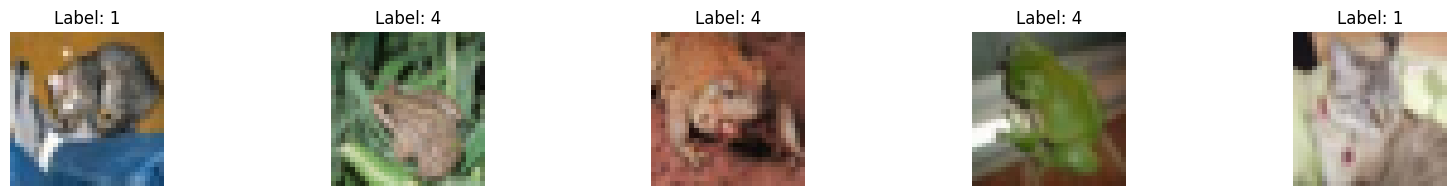

In [48]:
plt.figure(figsize=(20, 2)) 
print("Displaying first 5 testing images:")

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i])  # Ensure correct type
    plt.axis('off')
    plt.title(f"Label: {y_test[i]}")
plt.show()

In [49]:
y_test = to_categorical(y_test, 6)

In [50]:
model_CIFAR.evaluate(X_test, y_test, verbose=1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2778 - loss: 5.1953


[5.161650657653809, 0.2776666581630707]

In [51]:
dat.groupby(['Stage', 'Class']).size()

Stage      Class
test       bird     1000
           cat      1000
           deer     1000
           dog      1000
           frog     1000
           horse    1000
train      bird     3000
           cat      3000
           deer     3000
           dog      3000
           frog     3000
           horse    3000
train/val  bird     5000
           cat      5000
           deer     5000
           dog      5000
           frog     5000
           horse    5000
dtype: int64

In [52]:
dat = dat.reset_index(drop=True)

In [53]:
dat

,Path,Class,Encoded_Class,Image,DataType,Stage
0,/code/Final-Project/data/BirdAI/bird_2930.jpg,bird,0,"[[[0.2509804, 0.3529412, 0.0627451], [0.270588...",synth,train
1,/code/Final-Project/data/BirdAI/bird_1439.jpg,bird,0,"[[[0.45882353, 0.4627451, 0.30588236], [0.4588...",synth,train
2,/code/Final-Project/data/BirdAI/bird_1595.jpg,bird,0,"[[[0.42745098, 0.45490196, 0.28235295], [0.486...",synth,train
3,/code/Final-Project/data/BirdAI/bird_2378.jpg,bird,0,"[[[0.36862746, 0.33333334, 0.20392157], [0.439...",synth,train
4,/code/Final-Project/data/BirdAI/bird_781.jpg,bird,0,"[[[0.42352942, 0.45882353, 0.19607843], [0.505...",synth,train
...,...,...,...,...,...,...
53995,NaN,dog,3,"[[[0.37254901960784315, 0.3843137254901961, 0....",real,test
53996,NaN,cat,1,"[[[0.26666666666666666, 0.17254901960784313, 0...",real,test
53997,NaN,cat,1,"[[[0.3176470588235294, 0.2235294117647059, 0.1...",real,test
53998,NaN,dog,3,"[[[0.0784313725490196, 0.058823529411764705, 0...",real,test


In [54]:
val_subset = dat[dat['Stage'] == 'train/val'][15000:].index

In [55]:
dat.loc[val_subset]

,Path,Class,Encoded_Class,Image,DataType,Stage
33000,NaN,bird,0,"[[[0.23137254901960785, 0.24705882352941178, 0...",real,train/val
33001,NaN,horse,5,"[[[0.3333333333333333, 0.4823529411764706, 0.2...",real,train/val
33002,NaN,deer,2,"[[[0.4980392156862745, 0.5215686274509804, 0.5...",real,train/val
33003,NaN,deer,2,"[[[0.1843137254901961, 0.20392156862745098, 0....",real,train/val
33004,NaN,dog,3,"[[[0.36470588235294116, 0.29411764705882354, 0...",real,train/val
...,...,...,...,...,...,...
47995,NaN,dog,3,"[[[0.6313725490196078, 0.6509803921568628, 0.6...",real,train/val
47996,NaN,deer,2,"[[[0.8862745098039215, 0.8980392156862745, 0.9...",real,train/val
47997,NaN,bird,0,"[[[0.7372549019607844, 0.7647058823529411, 0.7...",real,train/val
47998,NaN,bird,0,"[[[0.5686274509803921, 0.6313725490196078, 0.7...",real,train/val


In [56]:
dat.loc[val_subset, "Stage"] = "val"

In [57]:
dat.groupby(['Stage', 'Class']).size()

Stage      Class
test       bird     1000
           cat      1000
           deer     1000
           dog      1000
           frog     1000
           horse    1000
train      bird     3000
           cat      3000
           deer     3000
           dog      3000
           frog     3000
           horse    3000
train/val  bird     2514
           cat      2522
           deer     2488
           dog      2410
           frog     2537
           horse    2529
val        bird     2486
           cat      2478
           deer     2512
           dog      2590
           frog     2463
           horse    2471
dtype: int64

In [58]:
val_df = dat[dat['Stage'] == 'val']

In [59]:
len(val_df)

15000

In [60]:
train_df = dat[dat['Stage'] == 'train']
extra_train_df = dat[dat['Stage'] == 'train/val'].sample(frac=0.1)

In [61]:
train_df1 = pd.concat([train_df, extra_train_df])

In [62]:
train_df1 = train_df1.sample(frac=1.0)

In [63]:
train_df1.groupby(['DataType', 'Class']).size()

DataType  Class
real      bird      248
          cat       240
          deer      265
          dog       246
          frog      265
          horse     236
synth     bird     3000
          cat      3000
          deer     3000
          dog      3000
          frog     3000
          horse    3000
dtype: int64

In [64]:
X_train1 = np.array(train_df1['Image'].to_list())
y_train1 = np.array(train_df1['Encoded_Class'].to_list())
y_train1 = to_categorical(y_train1, 6)


In [65]:
X_train1.shape

(19500, 32, 32, 3)

In [66]:
y_train1.shape

(19500, 6)

In [67]:
y_train1

array([[0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0.],
       ...,
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.]])

In [68]:
val_x = np.array(val_df['Image'].to_list())
val_y = np.array(val_df['Encoded_Class'].to_list())

In [69]:
val_y = to_categorical(val_y, 6)

In [70]:
val_y.shape

(15000, 6)

In [71]:
model_CIFAR.compile(optimizer='adam', loss= 'categorical_crossentropy', metrics=['accuracy'])

In [72]:
model_CIFAR.fit(X_train1, y_train1, validation_data=(val_x, val_y), epochs=30, batch_size=120, verbose=2, callbacks = [early_stopping_callback])

Epoch 1/30
163/163 - 20s - 124ms/step - accuracy: 0.9390 - loss: 0.1839 - val_accuracy: 0.3715 - val_loss: 1.5972
Epoch 2/30
163/163 - 18s - 108ms/step - accuracy: 0.9473 - loss: 0.1428 - val_accuracy: 0.3869 - val_loss: 1.5691
Epoch 3/30
163/163 - 18s - 109ms/step - accuracy: 0.9493 - loss: 0.1346 - val_accuracy: 0.4269 - val_loss: 1.4836
Epoch 4/30
163/163 - 18s - 109ms/step - accuracy: 0.9557 - loss: 0.1189 - val_accuracy: 0.4315 - val_loss: 1.4871
Epoch 5/30
163/163 - 17s - 107ms/step - accuracy: 0.9571 - loss: 0.1183 - val_accuracy: 0.4366 - val_loss: 1.5423
Epoch 6/30
163/163 - 17s - 105ms/step - accuracy: 0.9589 - loss: 0.1120 - val_accuracy: 0.4598 - val_loss: 1.4058
Epoch 7/30
163/163 - 17s - 104ms/step - accuracy: 0.9617 - loss: 0.0999 - val_accuracy: 0.4518 - val_loss: 1.4980
Epoch 8/30
163/163 - 17s - 105ms/step - accuracy: 0.9658 - loss: 0.0936 - val_accuracy: 0.4661 - val_loss: 1.4180
Epoch 9/30
163/163 - 17s - 104ms/step - accuracy: 0.9649 - loss: 0.0957 - val_accuracy: 

In [73]:
model_CIFAR.evaluate(X_test, y_test, verbose=1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4938 - loss: 1.7667


[1.7342742681503296, 0.4961666762828827]

In [74]:
extra_train_df = dat[dat['Stage'] == 'train/val'].sample(frac=0.2)
train_df2 = pd.concat([train_df, extra_train_df])
train_df2 = train_df2.sample(frac=1.0) # shuffle dataset

In [75]:
train_df2.groupby(['DataType', 'Class']).size()

DataType  Class
real      bird      475
          cat       504
          deer      543
          dog       475
          frog      532
          horse     471
synth     bird     3000
          cat      3000
          deer     3000
          dog      3000
          frog     3000
          horse    3000
dtype: int64

In [76]:
X_train2 = np.array(train_df2['Image'].to_list())
y_train2 = np.array(train_df2['Encoded_Class'].to_list())
y_train2 = to_categorical(y_train2, 6)

In [77]:
print(X_train2.shape)
print(y_train2.shape)

(21000, 32, 32, 3)
(21000, 6)


In [78]:
model_CIFAR.compile(optimizer='adam', loss= 'categorical_crossentropy', metrics=['accuracy'])
model_CIFAR.fit(X_train2, y_train2, validation_data=(val_x, val_y), epochs=30, batch_size=128, verbose=2, callbacks = [early_stopping_callback])

Epoch 1/30
165/165 - 21s - 127ms/step - accuracy: 0.9228 - loss: 0.2131 - val_accuracy: 0.4967 - val_loss: 1.3128
Epoch 2/30
165/165 - 19s - 113ms/step - accuracy: 0.9318 - loss: 0.1809 - val_accuracy: 0.5245 - val_loss: 1.2514
Epoch 3/30
165/165 - 19s - 113ms/step - accuracy: 0.9377 - loss: 0.1665 - val_accuracy: 0.5195 - val_loss: 1.2447
Epoch 4/30
165/165 - 19s - 113ms/step - accuracy: 0.9382 - loss: 0.1644 - val_accuracy: 0.5445 - val_loss: 1.2081
Epoch 5/30
165/165 - 19s - 114ms/step - accuracy: 0.9477 - loss: 0.1412 - val_accuracy: 0.5305 - val_loss: 1.2738
Epoch 6/30
165/165 - 19s - 113ms/step - accuracy: 0.9492 - loss: 0.1366 - val_accuracy: 0.5409 - val_loss: 1.2230
Epoch 7/30
165/165 - 21s - 127ms/step - accuracy: 0.9530 - loss: 0.1267 - val_accuracy: 0.5552 - val_loss: 1.2079
Epoch 8/30
165/165 - 18s - 112ms/step - accuracy: 0.9544 - loss: 0.1167 - val_accuracy: 0.5585 - val_loss: 1.2242
Epoch 9/30
165/165 - 19s - 113ms/step - accuracy: 0.9558 - loss: 0.1212 - val_accuracy: 

In [79]:
model_CIFAR.evaluate(X_test, y_test, verbose=1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5651 - loss: 1.3294


[1.3371970653533936, 0.5543333292007446]

In [80]:
extra_train_df = dat[dat['Stage'] == 'train/val'].sample(frac=0.3)
train_df3 = pd.concat([train_df, extra_train_df])
train_df3 = train_df3.sample(frac=1.0) # shuffle dataset
X_train3 = np.array(train_df3['Image'].to_list())
y_train3 = np.array(train_df3['Encoded_Class'].to_list())
y_train3 = to_categorical(y_train3, 6)

In [81]:
train_df3.groupby(['DataType', 'Class']).size()

DataType  Class
real      bird      771
          cat       776
          deer      719
          dog       748
          frog      760
          horse     726
synth     bird     3000
          cat      3000
          deer     3000
          dog      3000
          frog     3000
          horse    3000
dtype: int64

In [82]:
print(X_train3.shape)
print(y_train3.shape)

(22500, 32, 32, 3)
(22500, 6)


In [83]:
model_CIFAR.compile(optimizer='adam', loss= 'categorical_crossentropy', metrics=['accuracy'])
model_CIFAR.fit(X_train3, y_train3, validation_data=(val_x, val_y), epochs=30, batch_size=120, verbose=2, callbacks = [early_stopping_callback])

Epoch 1/30
188/188 - 23s - 122ms/step - accuracy: 0.9090 - loss: 0.2505 - val_accuracy: 0.5678 - val_loss: 1.1401
Epoch 2/30
188/188 - 21s - 110ms/step - accuracy: 0.9197 - loss: 0.2163 - val_accuracy: 0.5691 - val_loss: 1.1496
Epoch 3/30
188/188 - 41s - 217ms/step - accuracy: 0.9312 - loss: 0.1894 - val_accuracy: 0.5825 - val_loss: 1.1236
Epoch 4/30
188/188 - 20s - 107ms/step - accuracy: 0.9320 - loss: 0.1834 - val_accuracy: 0.5815 - val_loss: 1.1124
Epoch 5/30
188/188 - 21s - 110ms/step - accuracy: 0.9364 - loss: 0.1708 - val_accuracy: 0.5814 - val_loss: 1.1128
Epoch 6/30
188/188 - 21s - 110ms/step - accuracy: 0.9445 - loss: 0.1490 - val_accuracy: 0.5927 - val_loss: 1.1289
Epoch 7/30
188/188 - 21s - 111ms/step - accuracy: 0.9460 - loss: 0.1443 - val_accuracy: 0.5826 - val_loss: 1.1830
Epoch 8/30
188/188 - 20s - 109ms/step - accuracy: 0.9500 - loss: 0.1333 - val_accuracy: 0.5923 - val_loss: 1.1513
Epoch 9/30
188/188 - 41s - 219ms/step - accuracy: 0.9547 - loss: 0.1236 - val_accuracy: 

In [84]:
model_CIFAR.evaluate(X_test, y_test, verbose=1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6066 - loss: 1.4364


[1.4341367483139038, 0.6113333106040955]

In [85]:
extra_train_df = dat[dat['Stage'] == 'train/val'].sample(frac=0.4)
train_df4 = pd.concat([train_df, extra_train_df])
train_df4 = train_df4.sample(frac=1.0) # shuffle dataset
X_train4 = np.array(train_df4['Image'].to_list())
y_train4 = np.array(train_df4['Encoded_Class'].to_list())
y_train4 = to_categorical(y_train4, 6)

In [86]:
train_df4.groupby(['DataType', 'Class']).size()

DataType  Class
real      bird     1005
          cat       989
          deer     1017
          dog       964
          frog     1002
          horse    1023
synth     bird     3000
          cat      3000
          deer     3000
          dog      3000
          frog     3000
          horse    3000
dtype: int64

In [87]:
print(X_train4.shape)
print(y_train4.shape)

(24000, 32, 32, 3)
(24000, 6)


In [88]:
model_CIFAR.compile(optimizer='adam', loss= 'categorical_crossentropy', metrics=['accuracy'])
model_CIFAR.fit(X_train4, y_train4, validation_data=(val_x, val_y), epochs=30, batch_size=120, verbose=2, callbacks = [early_stopping_callback])

Epoch 1/30
200/200 - 25s - 125ms/step - accuracy: 0.9142 - loss: 0.2548 - val_accuracy: 0.5999 - val_loss: 1.0820
Epoch 2/30
200/200 - 22s - 108ms/step - accuracy: 0.9229 - loss: 0.2116 - val_accuracy: 0.6207 - val_loss: 1.0392
Epoch 3/30
200/200 - 22s - 109ms/step - accuracy: 0.9304 - loss: 0.1918 - val_accuracy: 0.6239 - val_loss: 1.0263
Epoch 4/30
200/200 - 22s - 109ms/step - accuracy: 0.9371 - loss: 0.1706 - val_accuracy: 0.6226 - val_loss: 1.0725
Epoch 5/30
200/200 - 23s - 115ms/step - accuracy: 0.9391 - loss: 0.1618 - val_accuracy: 0.6231 - val_loss: 1.0626
Epoch 6/30
200/200 - 23s - 117ms/step - accuracy: 0.9445 - loss: 0.1500 - val_accuracy: 0.6231 - val_loss: 1.1181
Epoch 7/30
200/200 - 21s - 104ms/step - accuracy: 0.9501 - loss: 0.1345 - val_accuracy: 0.6295 - val_loss: 1.0979
Epoch 8/30
200/200 - 42s - 208ms/step - accuracy: 0.9527 - loss: 0.1277 - val_accuracy: 0.6157 - val_loss: 1.1578
Epoch 9/30
200/200 - 41s - 206ms/step - accuracy: 0.9516 - loss: 0.1264 - val_accuracy: 

In [89]:
model_CIFAR.evaluate(X_test, y_test, verbose=1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6186 - loss: 1.2403


[1.2505595684051514, 0.6186666488647461]

In [90]:
extra_train_df = dat[dat['Stage'] == 'train/val'].sample(frac=0.5)
train_df5 = pd.concat([train_df, extra_train_df])
train_df5 = train_df5.sample(frac=1.0) # shuffle dataset
X_train5 = np.array(train_df5['Image'].to_list())
y_train5 = np.array(train_df5['Encoded_Class'].to_list())
y_train5 = to_categorical(y_train5, 6)

In [91]:
train_df5.groupby(['DataType', 'Class']).size()

DataType  Class
real      bird     1226
          cat      1278
          deer     1249
          dog      1182
          frog     1289
          horse    1276
synth     bird     3000
          cat      3000
          deer     3000
          dog      3000
          frog     3000
          horse    3000
dtype: int64

In [92]:
print(X_train5.shape)
print(y_train5.shape)

(25500, 32, 32, 3)
(25500, 6)


In [93]:
model_CIFAR.compile(optimizer='adam', loss= 'categorical_crossentropy', metrics=['accuracy'])
model_CIFAR.fit(X_train5, y_train5, validation_data=(val_x, val_y), epochs=30, batch_size=120, verbose=2, callbacks = [early_stopping_callback])

Epoch 1/30
213/213 - 25s - 118ms/step - accuracy: 0.9163 - loss: 0.2456 - val_accuracy: 0.6180 - val_loss: 1.0543
Epoch 2/30
213/213 - 22s - 104ms/step - accuracy: 0.9301 - loss: 0.1973 - val_accuracy: 0.6389 - val_loss: 1.0018
Epoch 3/30
213/213 - 22s - 105ms/step - accuracy: 0.9355 - loss: 0.1842 - val_accuracy: 0.6404 - val_loss: 1.0217
Epoch 4/30
213/213 - 22s - 102ms/step - accuracy: 0.9405 - loss: 0.1654 - val_accuracy: 0.6285 - val_loss: 1.0685
Epoch 5/30
213/213 - 23s - 106ms/step - accuracy: 0.9467 - loss: 0.1515 - val_accuracy: 0.6381 - val_loss: 1.0625
Epoch 6/30
213/213 - 23s - 106ms/step - accuracy: 0.9471 - loss: 0.1440 - val_accuracy: 0.6401 - val_loss: 1.0757
Epoch 7/30
213/213 - 23s - 108ms/step - accuracy: 0.9519 - loss: 0.1335 - val_accuracy: 0.6439 - val_loss: 1.0901
Epoch 8/30
213/213 - 25s - 118ms/step - accuracy: 0.9547 - loss: 0.1280 - val_accuracy: 0.6424 - val_loss: 1.0885
Epoch 9/30
213/213 - 23s - 108ms/step - accuracy: 0.9582 - loss: 0.1142 - val_accuracy: 

In [94]:
model_CIFAR.evaluate(X_test, y_test, verbose=1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6438 - loss: 1.2768


[1.3089373111724854, 0.6399999856948853]

In [95]:
extra_train_df = dat[dat['Stage'] == 'train/val'].sample(frac=0.6)
train_df6 = pd.concat([train_df, extra_train_df])
train_df6 = train_df6.sample(frac=1.0) # shuffle dataset
X_train6 = np.array(train_df6['Image'].to_list())
y_train6 = np.array(train_df6['Encoded_Class'].to_list())
y_train6 = to_categorical(y_train6, 6)

In [96]:
train_df6.groupby(['DataType', 'Class']).size()

DataType  Class
real      bird     1503
          cat      1563
          deer     1494
          dog      1442
          frog     1502
          horse    1496
synth     bird     3000
          cat      3000
          deer     3000
          dog      3000
          frog     3000
          horse    3000
dtype: int64

In [97]:
print(X_train6.shape)
print(y_train6.shape)

(27000, 32, 32, 3)
(27000, 6)


In [98]:
model_CIFAR.compile(optimizer='adam', loss= 'categorical_crossentropy', metrics=['accuracy'])
model_CIFAR.fit(X_train6, y_train6, validation_data=(val_x, val_y), epochs=30, batch_size=120, verbose=2, callbacks = [early_stopping_callback])

Epoch 1/30
225/225 - 26s - 114ms/step - accuracy: 0.9252 - loss: 0.2325 - val_accuracy: 0.6479 - val_loss: 0.9989
Epoch 2/30
225/225 - 24s - 107ms/step - accuracy: 0.9351 - loss: 0.1882 - val_accuracy: 0.6387 - val_loss: 1.0499
Epoch 3/30
225/225 - 23s - 104ms/step - accuracy: 0.9394 - loss: 0.1736 - val_accuracy: 0.6531 - val_loss: 0.9806
Epoch 4/30
225/225 - 23s - 102ms/step - accuracy: 0.9472 - loss: 0.1491 - val_accuracy: 0.6537 - val_loss: 1.0740
Epoch 5/30
225/225 - 24s - 107ms/step - accuracy: 0.9487 - loss: 0.1448 - val_accuracy: 0.6460 - val_loss: 1.0525
Epoch 6/30
225/225 - 41s - 181ms/step - accuracy: 0.9521 - loss: 0.1322 - val_accuracy: 0.6535 - val_loss: 1.1199
Epoch 7/30
225/225 - 24s - 106ms/step - accuracy: 0.9581 - loss: 0.1158 - val_accuracy: 0.6587 - val_loss: 1.0890
Epoch 8/30
225/225 - 23s - 101ms/step - accuracy: 0.9594 - loss: 0.1156 - val_accuracy: 0.6511 - val_loss: 1.1243
Epoch 9/30
225/225 - 23s - 102ms/step - accuracy: 0.9631 - loss: 0.1031 - val_accuracy: 

In [99]:
model_CIFAR.evaluate(X_test, y_test, verbose=1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6619 - loss: 1.2558


[1.270346760749817, 0.6539999842643738]

In [100]:
extra_train_df = dat[dat['Stage'] == 'train/val'].sample(frac=0.7)
train_df7 = pd.concat([train_df, extra_train_df])
train_df7 = train_df7.sample(frac=1.0) # shuffle dataset
X_train7 = np.array(train_df7['Image'].to_list())
y_train7 = np.array(train_df7['Encoded_Class'].to_list())
y_train7 = to_categorical(y_train7, 6)

In [101]:
train_df7.groupby(['DataType', 'Class']).size()

DataType  Class
real      bird     1768
          cat      1807
          deer     1727
          dog      1670
          frog     1794
          horse    1734
synth     bird     3000
          cat      3000
          deer     3000
          dog      3000
          frog     3000
          horse    3000
dtype: int64

In [102]:
print(X_train7.shape)
print(y_train7.shape)

(28500, 32, 32, 3)
(28500, 6)


In [103]:
model_CIFAR.compile(optimizer='adam', loss= 'categorical_crossentropy', metrics=['accuracy'])
model_CIFAR.fit(X_train7, y_train7, validation_data=(val_x, val_y), epochs=30, batch_size=120, verbose=2, callbacks = [early_stopping_callback])

Epoch 1/30
238/238 - 27s - 115ms/step - accuracy: 0.9401 - loss: 0.1892 - val_accuracy: 0.6581 - val_loss: 1.0288
Epoch 2/30
238/238 - 25s - 103ms/step - accuracy: 0.9468 - loss: 0.1540 - val_accuracy: 0.6620 - val_loss: 1.0368
Epoch 3/30
238/238 - 25s - 103ms/step - accuracy: 0.9522 - loss: 0.1385 - val_accuracy: 0.6620 - val_loss: 1.0831
Epoch 4/30
238/238 - 25s - 104ms/step - accuracy: 0.9564 - loss: 0.1245 - val_accuracy: 0.6546 - val_loss: 1.1070
Epoch 5/30
238/238 - 41s - 173ms/step - accuracy: 0.9609 - loss: 0.1141 - val_accuracy: 0.6633 - val_loss: 1.1489
Epoch 6/30
238/238 - 25s - 106ms/step - accuracy: 0.9585 - loss: 0.1184 - val_accuracy: 0.6643 - val_loss: 1.1467
Epoch 7/30
238/238 - 25s - 105ms/step - accuracy: 0.9632 - loss: 0.1062 - val_accuracy: 0.6499 - val_loss: 1.1657
Epoch 8/30
238/238 - 25s - 104ms/step - accuracy: 0.9646 - loss: 0.1022 - val_accuracy: 0.6533 - val_loss: 1.2180
Epoch 9/30
238/238 - 25s - 105ms/step - accuracy: 0.9662 - loss: 0.0937 - val_accuracy: 

In [104]:
model_CIFAR.evaluate(X_test, y_test, verbose=1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6647 - loss: 1.1384


[1.1825422048568726, 0.6636666655540466]

In [105]:
extra_train_df = dat[dat['Stage'] == 'train/val'].sample(frac=1.0)
train_df10 = pd.concat([train_df, extra_train_df])
train_df10 = train_df10.sample(frac=1.0) # shuffle dataset
X_train10 = np.array(train_df10['Image'].to_list())
y_train10 = np.array(train_df10['Encoded_Class'].to_list())
y_train10 = to_categorical(y_train10, 6)

In [106]:
train_df10.groupby(['DataType', 'Class']).size()

DataType  Class
real      bird     2514
          cat      2522
          deer     2488
          dog      2410
          frog     2537
          horse    2529
synth     bird     3000
          cat      3000
          deer     3000
          dog      3000
          frog     3000
          horse    3000
dtype: int64

In [107]:
print(X_train10.shape)
print(y_train10.shape)

(33000, 32, 32, 3)
(33000, 6)


In [108]:
model_CIFAR.compile(optimizer='adam', loss= 'categorical_crossentropy', metrics=['accuracy'])
model_CIFAR.fit(X_train10, y_train10, validation_data=(val_x, val_y), epochs=30, batch_size=120, verbose=2, callbacks = [early_stopping_callback])

Epoch 1/30
275/275 - 31s - 114ms/step - accuracy: 0.9376 - loss: 0.1794 - val_accuracy: 0.6588 - val_loss: 1.0587
Epoch 2/30
275/275 - 28s - 103ms/step - accuracy: 0.9475 - loss: 0.1486 - val_accuracy: 0.6612 - val_loss: 1.1173
Epoch 3/30
275/275 - 28s - 102ms/step - accuracy: 0.9502 - loss: 0.1421 - val_accuracy: 0.6605 - val_loss: 1.1082
Epoch 4/30
275/275 - 28s - 100ms/step - accuracy: 0.9521 - loss: 0.1325 - val_accuracy: 0.6655 - val_loss: 1.1737
Epoch 5/30
275/275 - 27s - 100ms/step - accuracy: 0.9523 - loss: 0.1328 - val_accuracy: 0.6600 - val_loss: 1.1333
Epoch 6/30
275/275 - 28s - 103ms/step - accuracy: 0.9549 - loss: 0.1245 - val_accuracy: 0.6681 - val_loss: 1.1479
Epoch 7/30
275/275 - 28s - 102ms/step - accuracy: 0.9567 - loss: 0.1197 - val_accuracy: 0.6654 - val_loss: 1.2083
Epoch 8/30
275/275 - 28s - 102ms/step - accuracy: 0.9583 - loss: 0.1185 - val_accuracy: 0.6686 - val_loss: 1.2025
Epoch 9/30
275/275 - 28s - 101ms/step - accuracy: 0.9595 - loss: 0.1149 - val_accuracy: 

In [109]:
model_CIFAR.evaluate(X_test, y_test, verbose=1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6654 - loss: 1.2859


[1.3066097497940063, 0.6604999899864197]